# Step-by-Step Artificial Neural Network
## Predicting Deep-Ocean Currents from Argo Float Observations

**EARTHLAB 2026** — Tuesday Morning Practical (Alice Cicirello)

**Instructor:** Alice Cicirello

**Developed by:** Francesco Muschitiello
**Last updated by:** Alice Cicirello (13/06/2026)


---

### What are we doing?

In this practical, we will build an **Artificial Neural Network (ANN)** from scratch using **PyTorch** to predict deep-ocean current velocities from hydrographic observations. 

This is a real-world geoscience problem: we have temperature, salinity, and their spatial gradients measured by [Argo floats](https://argo.ucsd.edu/), and we want to reconstruct the ocean currents that are much harder to observe directly.

The structure is based on L2: The elements of a Fully Connected Neural Network

Ocean currents are governed by complex, nonlinear relationships between temperature, salinity, pressure gradients, and the Coriolis effect. While geostrophic balance gives us a first-order approximation, real currents deviate from this in important ways. ANNs can learn these nonlinear mappings directly from data, without us having to specify the exact functional form.

### The dataset

Our data comes from Argo float observations, gridded into spatial cells. For each cell, we have:

| Column | Description | Units |
|--------|-------------|-------|
| `cell_id` | Unique identifier for each spatial cell | — |
| `lat`, `lon` | Latitude and longitude of the cell centre | degrees |
| `obs_u` | Eastward (zonal) current velocity | m/s |
| `obs_v` | Northward (meridional) current velocity | m/s |
| `theta` | Potential temperature | °C |
| `salt` | Salinity | g/kg |
| `dT_dx`, `dT_dy` | Zonal and meridional temperature gradients | °C/100 km |
| `dS_dx`, `dS_dy` | Zonal and meridional salinity gradients | g/kg/100 km |
| `f_coriolis` | Coriolis parameter | s⁻¹ |
| `n_cycles` | Number of Argo cycles contributing to the cell | — |

We will use the hydrographic variables (`theta`, `salt`, gradients, `f_coriolis`) to **predict** the current velocities (`obs_u`, `obs_v`). This is a **multi-output regression** problem — our network has two outputs.

### What you will learn

1. How to prepare geoscience data for a neural network
2. How to build and train an ANN in PyTorch
3. How to evaluate model performance and diagnose issues
4. How to visualise predictions spatially

Let's get started!

---
## 1. Import Libraries

We need several libraries:
- **PyTorch** (`torch`, `torch.nn`, `torch.optim`): our deep learning framework
- **pandas**: for loading and exploring tabular data
- **numpy**: for numerical operations
- **matplotlib**: for plotting
- **scikit-learn**: for data preprocessing (scaling) and evaluation metrics

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
# For reproducibility — setting seeds so everyone gets the same results
torch.manual_seed(42)
np.random.seed(42)

# Check if a GPU is available (useful but not required)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
import cartopy.crs as ccrs
import cartopy.feature as cfeature


Using device: cpu


---
## 2. Load the Data

We have three CSV files:
- **`train.csv`** — 5159 ocean grid cells with both input features and observed current velocities. We will use this to train and validate our model.
- **`gaps_to_predict.csv`** — 2272 held-out cells with input features only. These simulate "gaps" in our observational coverage.
- **`gaps_answers.csv`** — The true velocities for the held-out cells (we will use these only at the end, to evaluate how well our model fills the gaps).

Let's load and explore the training data first.

In [3]:
# Path to the data (relative to this notebook's location)
data_dir = '../data/argo_current_reconstruction/'

# Load training data
df_train = pd.read_csv(data_dir + 'train.csv')

print(f"Training data shape: {df_train.shape}")
print(f"Number of training cells: {len(df_train)}")
print()
df_train.head(10)

Training data shape: (5159, 13)
Number of training cells: 5159



,cell_id,lat,lon,theta,salt,dT_dx,dT_dy,dS_dx,dS_dy,f_coriolis,obs_u,obs_v,n_cycles
0,0,-69.0,-179.0,1.0547,34.7201,0.03990,-0.01218,-0.00047,-0.00031,-0.000136,0.0123,0.0023,15
1,1,-67.0,-179.0,1.0310,34.7188,0.02851,0.04905,0.00128,0.00142,-0.000134,0.0484,-0.0258,33
2,2,-65.0,-179.0,1.5307,34.7291,0.08154,0.34278,0.00157,0.00387,-0.000132,0.0333,-0.0115,92
3,3,-63.0,-179.0,2.0863,34.7107,0.01318,0.13886,-0.00138,-0.02035,-0.000130,0.0292,-0.0082,133
4,4,-61.0,-179.0,2.2675,34.6608,-0.03655,0.06899,0.01428,-0.02632,-0.000128,0.0247,0.0241,157
5,5,-59.0,-179.0,2.4632,34.5799,-0.03222,0.08763,0.01483,-0.03925,-0.000125,0.0336,0.0214,169
6,6,-57.0,-179.0,2.6892,34.4895,0.03095,0.15698,-0.01192,-0.05280,-0.000122,0.0585,-0.0107,182
7,7,-55.0,-179.0,3.1677,34.3794,0.12323,0.18182,-0.01632,-0.02368,-0.000119,0.0193,-0.0280,141
8,8,-53.0,-179.0,3.2625,34.3785,0.27833,-0.07225,-0.03759,0.01427,-0.000116,0.0021,-0.0472,201
9,9,-51.0,-179.0,3.0050,34.4226,0.12479,-0.07108,-0.01565,0.01344,-0.000113,0.0034,-0.0220,206


In [4]:
# Quick statistical summary — useful for spotting issues and understanding value ranges
df_train.describe()#

,cell_id,lat,lon,theta,salt,dT_dx,dT_dy,dS_dx,dS_dy,f_coriolis,obs_u,obs_v,n_cycles
count,5159.000000,5159.000000,5159.000000,5159.000000,5159.000000,5159.000000,5159.000000,5159.000000,5159.000000,5159.000000,5159.000000,5159.000000,5159.000000
mean,3705.733669,-13.256251,-15.866059,4.105035,34.579465,0.007767,0.038024,0.000893,-0.000959,-0.000029,0.005931,-0.000016,168.033534
std,2147.065486,35.553108,110.655352,1.758095,0.471182,0.090181,0.152732,0.010866,0.019574,0.000079,0.024657,0.014278,84.160355
min,0.000000,-75.000000,-179.000000,-0.823800,22.269100,-1.070560,-1.760740,-0.117680,-0.137280,-0.000141,-0.175000,-0.125100,12.000000
25%,1845.500000,-43.000000,-119.000000,3.195850,34.393700,-0.018215,-0.027635,-0.001490,-0.004460,-0.000099,-0.006200,-0.002700,110.000000
50%,3677.000000,-17.000000,-27.000000,4.244400,34.534700,0.000580,0.017000,0.000250,0.001000,-0.000043,0.000100,0.000200,161.000000
75%,5558.500000,15.000000,81.000000,4.816850,34.698000,0.017300,0.080795,0.002430,0.006990,0.000038,0.009300,0.003300,218.000000
max,7430.000000,79.000000,179.000000,13.823400,38.770400,0.985060,1.438450,0.112150,0.110440,0.000143,0.175400,0.190300,595.000000


In [6]:
# Check for missing values — neural networks cannot handle NaNs!
print("Missing values per column:")
print(df_train.isnull().sum())
print(f"\nTotal missing values: {df_train.isnull().sum().sum()}")

Missing values per column:
cell_id       0
lat           0
lon           0
theta         0
salt          0
dT_dx         0
dT_dy         0
dS_dx         0
dS_dy         0
f_coriolis    0
obs_u         0
obs_v         0
n_cycles      0
dtype: int64

Total missing values: 0


### Quick look at the spatial distribution

Let's plot where our training data is located and what the currents look like.

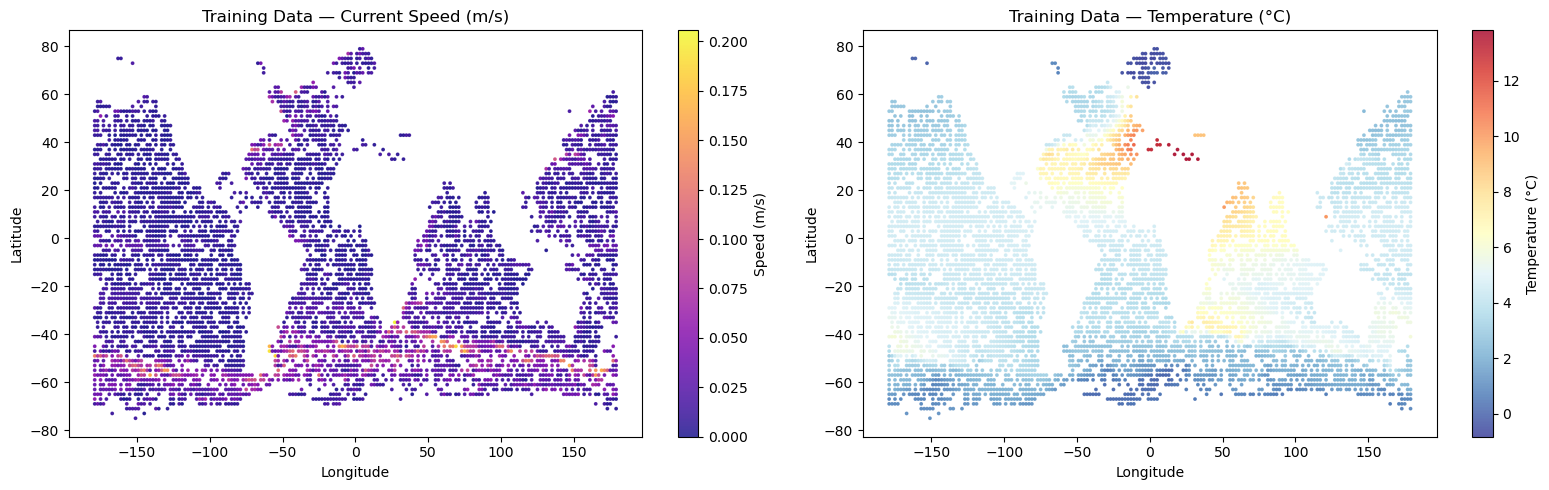

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot current speed
speed = np.sqrt(df_train['obs_u']**2 + df_train['obs_v']**2)
sc = axes[0].scatter(df_train['lon'], df_train['lat'], c=speed, s=3, cmap='plasma', alpha=0.8)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Training Data — Current Speed (m/s)')
plt.colorbar(sc, ax=axes[0], label='Speed (m/s)')

# Plot temperature
sc2 = axes[1].scatter(df_train['lon'], df_train['lat'], c=df_train['theta'], s=3, cmap='RdYlBu_r', alpha=0.8)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Training Data — Temperature (°C)')
plt.colorbar(sc2, ax=axes[1], label='Temperature (°C)')

plt.tight_layout()
plt.show()

---
## 3. Feature Selection and Target Definition

Now we need to decide which columns are our **inputs** (features) and which are our **outputs** (targets).

**Input features** (what the network sees):
- `theta` — temperature tells us about water masses and stratification
- `salt` — salinity is another key water-mass tracer
- `dT_dx`, `dT_dy` — temperature gradients are related to currents via thermal wind
- `dS_dx`, `dS_dy` — salinity gradients also contribute to density gradients
- `f_coriolis` — the Coriolis parameter varies with latitude and is fundamental to geostrophic balance

**Targets** (what we want to predict):
- `obs_u` — eastward current velocity
- `obs_v` — northward current velocity

**Why not include `lat`, `lon`, `cell_id`, or `n_cycles`?**
- `cell_id` is just an identifier, it carries no physical information
- `lat` and `lon` are already implicitly captured by `f_coriolis` (which depends on latitude) and by the spatial gradients. Including raw coordinates can cause the network to memorise locations rather than learn physical relationships
- `n_cycles` describes data quality, not ocean physics — we leave it out to keep things clean

In [8]:
# Define feature and target columns
feature_columns = ['theta', 'salt', 'dT_dx', 'dT_dy', 'dS_dx', 'dS_dy', 'f_coriolis']
target_columns = ['obs_u', 'obs_v']

print(f"Number of input features: {len(feature_columns)}")
print(f"Number of output targets: {len(target_columns)}")
print(f"\nFeatures: {feature_columns}")
print(f"Targets:  {target_columns}")

Number of input features: 7
Number of output targets: 2

Features: ['theta', 'salt', 'dT_dx', 'dT_dy', 'dS_dx', 'dS_dy', 'f_coriolis']
Targets:  ['obs_u', 'obs_v']


In [9]:
# Extract feature matrix X and target matrix y
X_all = df_train[feature_columns].values  # shape: (5159, 7)
y_all = df_train[target_columns].values    # shape: (5159, 2)

print(f"Feature matrix shape: {X_all.shape}")
print(f"Target matrix shape:  {y_all.shape}")

Feature matrix shape: (5159, 7)
Target matrix shape:  (5159, 2)


---
## 4. Train/Validation Split

We split our training data into two subsets:
- **Training set (80%)**: used to update the network weights
- **Validation set (20%)**: used to monitor performance on unseen data during training

**Why do we need a validation set?** If we only looked at training loss, we wouldn't know whether our model is **overfitting** — memorising the training data rather than learning generalisable patterns. The validation loss tells us how well the model performs on data it hasn't been trained on. If training loss keeps dropping but validation loss starts rising, that's a clear sign of overfitting.

In [10]:
# Split into training and validation sets (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

print(f"Training samples:   {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Training samples:   4127
Validation samples: 1032


---
## 5. Feature Scaling

Neural networks work best when all input features are on a similar scale. Our features have very different ranges:
- Temperature (`theta`): might range from -2°C to 30°C
- Coriolis parameter (`f_coriolis`): around 10⁻⁵ to 10⁻⁴ s⁻¹
- Gradients: potentially very small numbers

**StandardScaler** transforms each feature to have **zero mean** and **unit variance**:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

This ensures that no single feature dominates the learning process simply because it has larger numerical values.

If in doubt, recheck L1: Fundamentals of machine learning

**Important**: We fit the scaler on the **training data only**, then apply the same transformation to validation and test data. This prevents information leakage — the model should not have any knowledge of the validation/test data statistics.

In [11]:
# Fit scaler on training features ONLY
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)

# Transform validation features using the SAME scaler (no re-fitting!)
X_val_scaled = scaler_X.transform(X_val)

# Also scale the targets — this helps training stability
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)

# Verify scaling worked
print("Training features — mean (should be ~0):")
print(np.round(X_train_scaled.mean(axis=0), 4))
print("\nTraining features — std (should be ~1):")
print(np.round(X_train_scaled.std(axis=0), 4))

Training features — mean (should be ~0):
[-0.  0.  0. -0. -0.  0. -0.]

Training features — std (should be ~1):
[1. 1. 1. 1. 1. 1. 1.]


---
## 6. Convert to PyTorch Tensors and Create DataLoaders

PyTorch works with its own data type called **tensors** (similar to NumPy arrays, but with automatic differentiation support). We need to:

1. Convert our NumPy arrays to PyTorch tensors
2. Wrap them in `TensorDataset` objects
3. Create `DataLoader` objects that handle **batching**

### What is batching?

Instead of feeding all 4127 training samples through the network at once, we process them in small **batches** (e.g., 64 samples at a time). This has several benefits:
- Uses less memory
- Introduces helpful noise in the gradient estimates (acts as regularisation)
- Often leads to faster convergence

One full pass through all batches = one **epoch**.

In [12]:
# Convert to PyTorch tensors (float32 is standard for neural networks)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Create DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Number of training batches per epoch: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

# Quick check: look at one batch
sample_X, sample_y = next(iter(train_loader))
print(f"\nSample batch — features shape: {sample_X.shape}, targets shape: {sample_y.shape}")

Batch size: 64
Number of training batches per epoch: 65
Number of validation batches: 17

Sample batch — features shape: torch.Size([64, 7]), targets shape: torch.Size([64, 2])


---
## 7. Define the ANN Architecture

Now comes the exciting part — building our neural network!

### Architecture choices

We will build a **feedforward neural network** (also called a Multi-Layer Perceptron, MLP) with:
- **Input layer**: 7 neurons (one per feature)
- **Hidden layer 1**: 64 neurons
- **Hidden layer 2**: 32 neurons
- **Hidden layer 3**: 16 neurons
- **Output layer**: 2 neurons (one for `obs_u`, one for `obs_v`)

Question: is this a good architecture? Can you think of a better one? 

### What does each component do?

- **`nn.Linear(in, out)`**: A fully connected layer. Each input neuron is connected to every output neuron with a learnable weight. Computes $\mathbf{y} = \mathbf{W}\mathbf{x} + \mathbf{b}$.

- **`nn.ReLU()`**: The Rectified Linear Unit activation function: $\text{ReLU}(x) = \max(0, x)$. Without activation functions, stacking linear layers would just give us another linear layer — we need nonlinearity to learn complex patterns!

- We do **not** apply an activation function after the output layer, because this is a regression problem — we want the network to output any real number, not just positive values.

### Why this architecture?

We start with a moderately simple network. The decreasing layer sizes (64 → 32 → 16) encourage the network to learn increasingly compressed representations. With 7 inputs and 2 outputs, this is a reasonable starting point — complex enough to capture nonlinear patterns, but not so large that it overfits easily.

In [13]:
class CurrentPredictor(nn.Module):
    """
    A feedforward neural network for predicting ocean current velocities
    from hydrographic observations.
    """
    
    def __init__(self, n_inputs=7, n_outputs=2):
        super(CurrentPredictor, self).__init__()
        
        # Define the layers
        self.network = nn.Sequential(
            # Hidden layer 1: 7 inputs -> 64 neurons
            nn.Linear(n_inputs, 64),
            nn.ReLU(),
            
            # Hidden layer 2: 64 -> 32 neurons
            nn.Linear(64, 32),
            nn.ReLU(),
            
            # Hidden layer 3: 32 -> 16 neurons
            nn.Linear(32, 16),
            nn.ReLU(),
            
            # Output layer: 16 -> 2 outputs (u and v)
            # No activation function here — regression output!
            nn.Linear(16, n_outputs)
        )
    
    def forward(self, x):
        """Forward pass: push data through the network."""
        return self.network(x)


# Create the model and move it to the appropriate device
model = CurrentPredictor(n_inputs=7, n_outputs=2).to(device)

# Print the model architecture
print(model)
print()

CurrentPredictor(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=2, bias=True)
  )
)



In [14]:
# Count the total number of learnable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print()

# Break down by layer
print("Parameter breakdown:")
for name, param in model.named_parameters():
    print(f"  {name:30s} shape={str(list(param.shape)):15s} params={param.numel():,}")

Total parameters:     3,154
Trainable parameters: 3,154

Parameter breakdown:
  network.0.weight               shape=[64, 7]         params=448
  network.0.bias                 shape=[64]            params=64
  network.2.weight               shape=[32, 64]        params=2,048
  network.2.bias                 shape=[32]            params=32
  network.4.weight               shape=[16, 32]        params=512
  network.4.bias                 shape=[16]            params=16
  network.6.weight               shape=[2, 16]         params=32
  network.6.bias                 shape=[2]             params=2


---
## 8. Define Loss Function and Optimiser

### Loss function: Mean Squared Error (MSE)

The loss function measures how wrong our predictions are. For regression, **MSE** is the standard choice:

$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

It penalises large errors more heavily than small ones (because of the squaring), which encourages the network to avoid big mistakes.

### Optimiser: Adam

The optimiser controls *how* we update the network weights based on the gradients. **Adam** (Adaptive Moment Estimation) is a popular choice because:
- It adapts the learning rate for each parameter individually
- It uses momentum to smooth out noisy gradients
- It generally works well "out of the box"

The **learning rate** (here `0.001`) controls how big each weight update step is. Too large and the model overshoots; too small and training is painfully slow.

In [15]:
# Loss function
criterion = nn.MSELoss()

# Optimiser
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss function: {criterion}")
print(f"Optimiser:     Adam (lr={learning_rate})")

Loss function: MSELoss()
Optimiser:     Adam (lr=0.001)


---
## 9. Training Loop

This is where the learning happens! In each **epoch**, we:

1. **Forward pass**: Feed a batch of data through the network to get predictions
2. **Compute loss**: Measure how far off the predictions are from the true values
3. **Backward pass (backpropagation)**: Compute the gradient of the loss with respect to every weight in the network
4. **Update weights**: The optimiser adjusts the weights in the direction that reduces the loss

We repeat this for every batch in the training set (that's one epoch), and then do many epochs until the model converges.

After each epoch, we also evaluate the model on the validation set (without updating weights) to monitor for overfitting.

In [16]:
# Training configuration
n_epochs = 200
print_every = 20  # Print progress every N epochs

# Lists to store loss history for plotting
train_losses = []
val_losses = []

print(f"Training for {n_epochs} epochs...")
print(f"{'Epoch':>6s} | {'Train Loss':>12s} | {'Val Loss':>12s}")
print("-" * 38)

for epoch in range(n_epochs):
    
    # =====================
    # TRAINING PHASE
    # =====================
    model.train()  # Set model to training mode
    epoch_train_loss = 0.0
    n_train_batches = 0
    
    for X_batch, y_batch in train_loader:
        # Move data to device (GPU if available)
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Step 1: Forward pass — get predictions
        predictions = model(X_batch)
        
        # Step 2: Compute loss
        loss = criterion(predictions, y_batch)
        
        # Step 3: Backward pass — compute gradients
        optimizer.zero_grad()  # Clear old gradients first!
        loss.backward()        # Compute new gradients
        
        # Step 4: Update weights
        optimizer.step()
        
        epoch_train_loss += loss.item()
        n_train_batches += 1
    
    avg_train_loss = epoch_train_loss / n_train_batches
    
    # =====================
    # VALIDATION PHASE
    # =====================
    model.eval()  # Set model to evaluation mode
    epoch_val_loss = 0.0
    n_val_batches = 0
    
    with torch.no_grad():  # No gradient computation needed for validation
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            
            epoch_val_loss += loss.item()
            n_val_batches += 1
    
    avg_val_loss = epoch_val_loss / n_val_batches
    
    # Store losses
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # Print progress
    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(f"{epoch+1:6d} | {avg_train_loss:12.6f} | {avg_val_loss:12.6f}")

print("-" * 38)
print(f"Training complete! Final val loss: {val_losses[-1]:.6f}")

Training for 200 epochs...
 Epoch |   Train Loss |     Val Loss
--------------------------------------
     1 |     0.828553 |     0.551379
    20 |     0.355732 |     0.352057
    40 |     0.316617 |     0.343324
    60 |     0.297682 |     0.342374
    80 |     0.279618 |     0.345533
   100 |     0.267507 |     0.352724
   120 |     0.256378 |     0.346262
   140 |     0.256976 |     0.347994
   160 |     0.245064 |     0.350516
   180 |     0.242679 |     0.364435
   200 |     0.230404 |     0.373516
--------------------------------------
Training complete! Final val loss: 0.373516


---
## 10. Plot Learning Curves: Training and Validation Loss Curves

The loss curves are one of the most important diagnostic tools for neural networks. We are looking for:

- **Good fit**: Both training and validation loss decrease and stabilise at a similar level
- **Overfitting**: Training loss keeps decreasing, but validation loss starts increasing (the model is memorising training data)
- **Underfitting**: Both losses remain high (the model is too simple to capture the patterns)

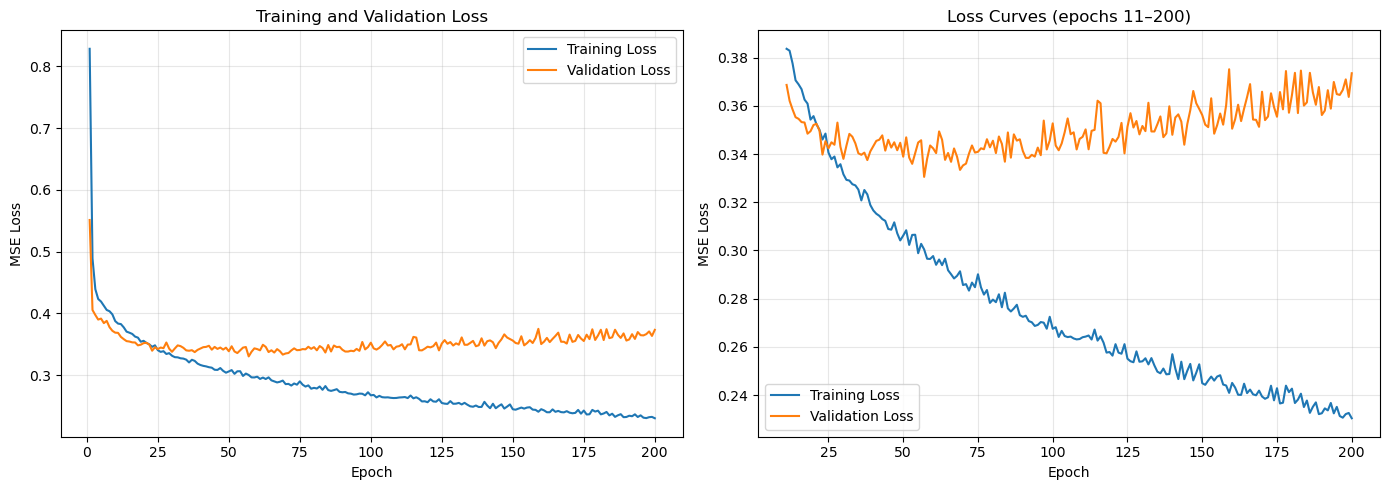


Final training loss:   0.230404
Final validation loss:  0.373516
Ratio (val/train):      1.62  (close to 1.0 = good, >> 1.0 = overfitting)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full loss curve
axes[0].plot(range(1, n_epochs + 1), train_losses, label='Training Loss', linewidth=1.5)
axes[0].plot(range(1, n_epochs + 1), val_losses, label='Validation Loss', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoomed in (skip first 10 epochs to see detail)
start_epoch = 10
axes[1].plot(range(start_epoch + 1, n_epochs + 1), train_losses[start_epoch:], 
             label='Training Loss', linewidth=1.5)
axes[1].plot(range(start_epoch + 1, n_epochs + 1), val_losses[start_epoch:], 
             label='Validation Loss', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title(f'Loss Curves (epochs {start_epoch + 1}–{n_epochs})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal training loss:   {train_losses[-1]:.6f}")
print(f"Final validation loss:  {val_losses[-1]:.6f}")
print(f"Ratio (val/train):      {val_losses[-1] / train_losses[-1]:.2f}  "
      f"(close to 1.0 = good, >> 1.0 = overfitting)")

**Interpreting the loss curves:** - recheck L1: Fundamentals of machine learning

- If both curves converge to similar values, our model is generalising well.
- If there is a noticeable gap (validation loss much higher than training loss), we may need regularisation (e.g., dropout, weight decay) or a simpler model... check L1! 
- If both losses are still decreasing at epoch 200, we might benefit from training longer.

---
## 11. Evaluate on Held-Out Gaps

Now for the real test: can our network predict ocean currents in **locations it has never seen**?

We load the `gaps_to_predict.csv` file (input features only), make predictions using our trained model, and then compare with the true values in `gaps_answers.csv`.

In [18]:
# Load the held-out data
df_gaps = pd.read_csv(data_dir + 'gaps_to_predict.csv')
df_answers = pd.read_csv(data_dir + 'gaps_answers.csv')

print(f"Gaps to predict: {len(df_gaps)} cells")
print(f"Answers available: {len(df_answers)} cells")
print(f"\nGap features columns: {list(df_gaps.columns)}")
print(f"Answer columns: {list(df_answers.columns)}")

df_gaps.head()

Gaps to predict: 2272 cells
Answers available: 2272 cells

Gap features columns: ['cell_id', 'lat', 'lon', 'theta', 'salt', 'dT_dx', 'dT_dy', 'dS_dx', 'dS_dy', 'f_coriolis']
Answer columns: ['cell_id', 'lat', 'lon', 'obs_u', 'obs_v', 'obs_speed']


,cell_id,lat,lon,theta,salt,dT_dx,dT_dy,dS_dx,dS_dy,f_coriolis
0,14,-39.0,-179.0,5.7979,34.4110,-0.01490,-0.07510,-0.00816,-0.00669,-0.000092
1,15,-37.0,-179.0,5.6523,34.3995,-0.13348,-0.07006,-0.01381,-0.00651,-0.000088
2,16,-35.0,-179.0,5.4062,34.3807,-0.15431,-0.09240,-0.01104,-0.00530,-0.000084
3,24,-5.0,-179.0,4.5665,34.5416,0.00844,0.03565,0.00042,0.00276,-0.000013
4,26,-1.0,-179.0,4.5285,34.5520,-0.01002,0.02553,0.00051,0.00090,-0.000003


In [21]:
# Extract features from the gaps data
X_gaps = df_gaps[feature_columns].values

# IMPORTANT: Scale using the SAME scaler fitted on training data
X_gaps_scaled = scaler_X.transform(X_gaps)

# Convert to PyTorch tensor
X_gaps_tensor = torch.tensor(X_gaps_scaled, dtype=torch.float32).to(device)

# Make predictions
model.eval()
with torch.no_grad():
    y_gaps_pred_scaled = model(X_gaps_tensor).cpu().numpy()

# Inverse-transform predictions back to original scale
y_gaps_pred = scaler_y.inverse_transform(y_gaps_pred_scaled)

print(f"Predictions shape: {y_gaps_pred.shape}")
print(f"Predicted u range: [{y_gaps_pred[:, 0].min():.4f}, {y_gaps_pred[:, 0].max():.4f}] m/s")
print(f"Predicted v range: [{y_gaps_pred[:, 1].min():.4f}, {y_gaps_pred[:, 1].max():.4f}] m/s")

Predictions shape: (2272, 2)
Predicted u range: [-0.1395, 0.1724] m/s
Predicted v range: [-0.1366, 0.1388] m/s


In [22]:
# Join predictions with the true answers using cell_id
df_results = df_gaps[['cell_id', 'lat', 'lon']].copy()
df_results['pred_u'] = y_gaps_pred[:, 0]
df_results['pred_v'] = y_gaps_pred[:, 1]

# Merge with true answers
df_results = df_results.merge(df_answers[['cell_id', 'obs_u', 'obs_v', 'obs_speed']], on='cell_id', how='left')

print(f"Results shape: {df_results.shape}")
df_results.head(10)

Results shape: (2272, 8)


,cell_id,lat,lon,pred_u,pred_v,obs_u,obs_v,obs_speed
0,14,-39.0,-179.0,0.000077,-0.003746,-0.0104,-0.0060,0.012007
1,15,-37.0,-179.0,-0.001381,0.001438,-0.0049,0.0028,0.005644
2,16,-35.0,-179.0,-0.005292,0.004034,-0.0074,-0.0079,0.010825
3,24,-5.0,-179.0,0.001732,-0.000597,0.0219,-0.0010,0.021923
4,26,-1.0,-179.0,-0.002756,-0.000070,0.0198,0.0035,0.020107
5,30,7.0,-179.0,-0.000634,-0.000251,-0.0108,0.0005,0.010812
6,34,15.0,-179.0,0.000285,-0.000163,-0.0030,-0.0038,0.004841
7,43,33.0,-179.0,-0.000742,0.000277,-0.0022,-0.0090,0.009265
8,46,39.0,-179.0,0.005544,-0.000344,0.0076,0.0007,0.007632
9,47,41.0,-179.0,0.002447,-0.001921,0.0083,-0.0024,0.008640


### Compute performance metrics

We use two standard metrics:
- **R² (coefficient of determination)**: 1.0 = perfect prediction, 0.0 = predicting the mean, negative = worse than the mean
- **RMSE (root mean squared error)**: in the same units as the target variable (m/s)

In [23]:
# Compute metrics for each component
r2_u = r2_score(df_results['obs_u'], df_results['pred_u'])
r2_v = r2_score(df_results['obs_v'], df_results['pred_v'])
rmse_u = np.sqrt(mean_squared_error(df_results['obs_u'], df_results['pred_u']))
rmse_v = np.sqrt(mean_squared_error(df_results['obs_v'], df_results['pred_v']))

# Combined speed metrics
actual_speed = np.sqrt(df_results['obs_u']**2 + df_results['obs_v']**2)
pred_speed = np.sqrt(df_results['pred_u']**2 + df_results['pred_v']**2)
r2_speed = r2_score(actual_speed, pred_speed)
rmse_speed = np.sqrt(mean_squared_error(actual_speed, pred_speed))

print("=" * 50)
print("MODEL PERFORMANCE ON HELD-OUT GAP CELLS")
print("=" * 50)
print(f"\n{'Component':<15s} {'R²':>8s} {'RMSE (m/s)':>12s}")
print("-" * 37)
print(f"{'Eastward (u)':<15s} {r2_u:8.4f} {rmse_u:12.6f}")
print(f"{'Northward (v)':<15s} {r2_v:8.4f} {rmse_v:12.6f}")
print(f"{'Speed |V|':<15s} {r2_speed:8.4f} {rmse_speed:12.6f}")
print("=" * 50)

MODEL PERFORMANCE ON HELD-OUT GAP CELLS

Component             R²   RMSE (m/s)
-------------------------------------
Eastward (u)      0.7537     0.012462
Northward (v)     0.5121     0.010455
Speed |V|         0.7126     0.012693


---
## 12. Visualisation of Results

Numbers alone don't tell the full story. Let's create several visualisations to understand *where* and *how* our model succeeds or fails.

### 12.1 Predicted vs Actual Scatter Plots

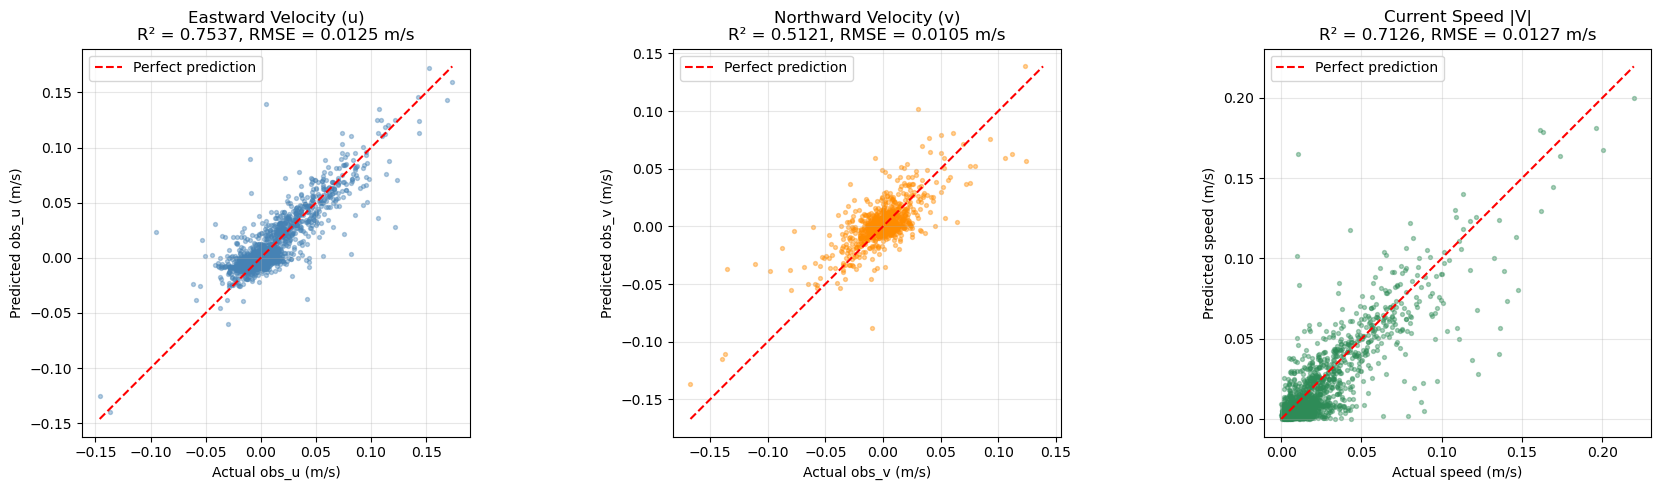

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Eastward component (u)
axes[0].scatter(df_results['obs_u'], df_results['pred_u'], s=8, alpha=0.4, c='steelblue')
lims_u = [min(df_results['obs_u'].min(), df_results['pred_u'].min()),
           max(df_results['obs_u'].max(), df_results['pred_u'].max())]
axes[0].plot(lims_u, lims_u, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual obs_u (m/s)')
axes[0].set_ylabel('Predicted obs_u (m/s)')
axes[0].set_title(f'Eastward Velocity (u)\nR² = {r2_u:.4f}, RMSE = {rmse_u:.4f} m/s')
axes[0].legend()
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# Northward component (v)
axes[1].scatter(df_results['obs_v'], df_results['pred_v'], s=8, alpha=0.4, c='darkorange')
lims_v = [min(df_results['obs_v'].min(), df_results['pred_v'].min()),
           max(df_results['obs_v'].max(), df_results['pred_v'].max())]
axes[1].plot(lims_v, lims_v, 'r--', linewidth=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual obs_v (m/s)')
axes[1].set_ylabel('Predicted obs_v (m/s)')
axes[1].set_title(f'Northward Velocity (v)\nR² = {r2_v:.4f}, RMSE = {rmse_v:.4f} m/s')
axes[1].legend()
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

# Speed
axes[2].scatter(actual_speed, pred_speed, s=8, alpha=0.4, c='seagreen')
lims_s = [0, max(actual_speed.max(), pred_speed.max())]
axes[2].plot(lims_s, lims_s, 'r--', linewidth=1.5, label='Perfect prediction')
axes[2].set_xlabel('Actual speed (m/s)')
axes[2].set_ylabel('Predicted speed (m/s)')
axes[2].set_title(f'Current Speed |V|\nR² = {r2_speed:.4f}, RMSE = {rmse_speed:.4f} m/s')
axes[2].legend()
axes[2].set_aspect('equal')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 12.2 Spatial Map: Predicted vs Actual Current Vectors

Let's plot the current vectors on a map to see how the spatial patterns compare.

C:\Users\ac685\anaconda3\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


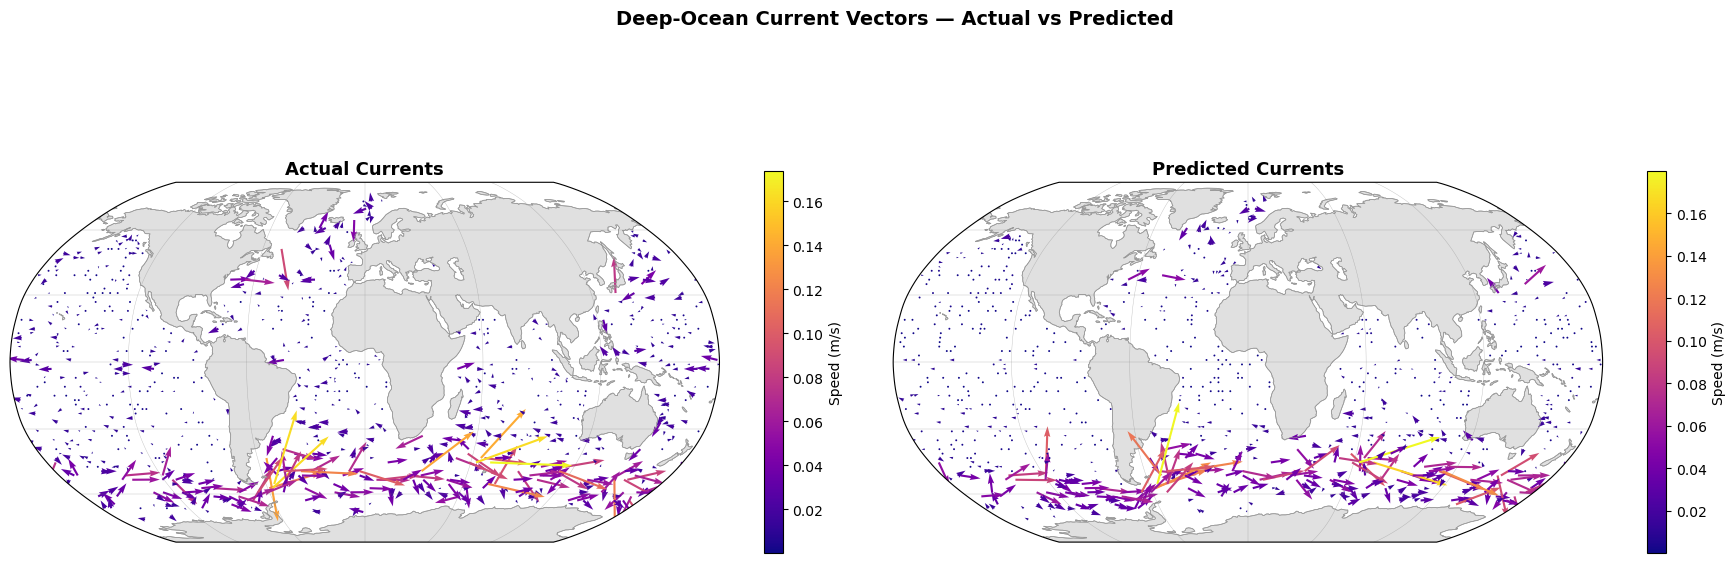

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                         subplot_kw={'projection': ccrs.Robinson()})

# Subsample for cleaner quiver plot
n_plot = min(len(df_results), 800)
np.random.seed(42)
idx = np.random.choice(len(df_results), size=n_plot, replace=False)
df_plot = df_results.iloc[idx]

for ax in axes:
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='#e0e0e0', edgecolor='#999999', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='#999999')
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

# Actual currents
speed_actual = np.sqrt(df_plot['obs_u']**2 + df_plot['obs_v']**2)
q1 = axes[0].quiver(df_plot['lon'].values, df_plot['lat'].values,
                     df_plot['obs_u'].values, df_plot['obs_v'].values,
                     speed_actual.values, cmap='plasma', scale=1.5,
                     width=0.003, transform=ccrs.PlateCarree())
axes[0].set_title('Actual Currents', fontsize=13, fontweight='bold')
plt.colorbar(q1, ax=axes[0], shrink=0.6, label='Speed (m/s)')

# Predicted currents
speed_pred = np.sqrt(df_plot['pred_u']**2 + df_plot['pred_v']**2)
q2 = axes[1].quiver(df_plot['lon'].values, df_plot['lat'].values,
                     df_plot['pred_u'].values, df_plot['pred_v'].values,
                     speed_pred.values, cmap='plasma', scale=1.5,
                     width=0.003, transform=ccrs.PlateCarree())
axes[1].set_title('Predicted Currents', fontsize=13, fontweight='bold')
plt.colorbar(q2, ax=axes[1], shrink=0.6, label='Speed (m/s)')

plt.suptitle('Deep-Ocean Current Vectors — Actual vs Predicted', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


### 12.3 Error Distribution

Let's look at the distribution of prediction errors. Ideally, errors should be centred around zero (no systematic bias) and have small spread.

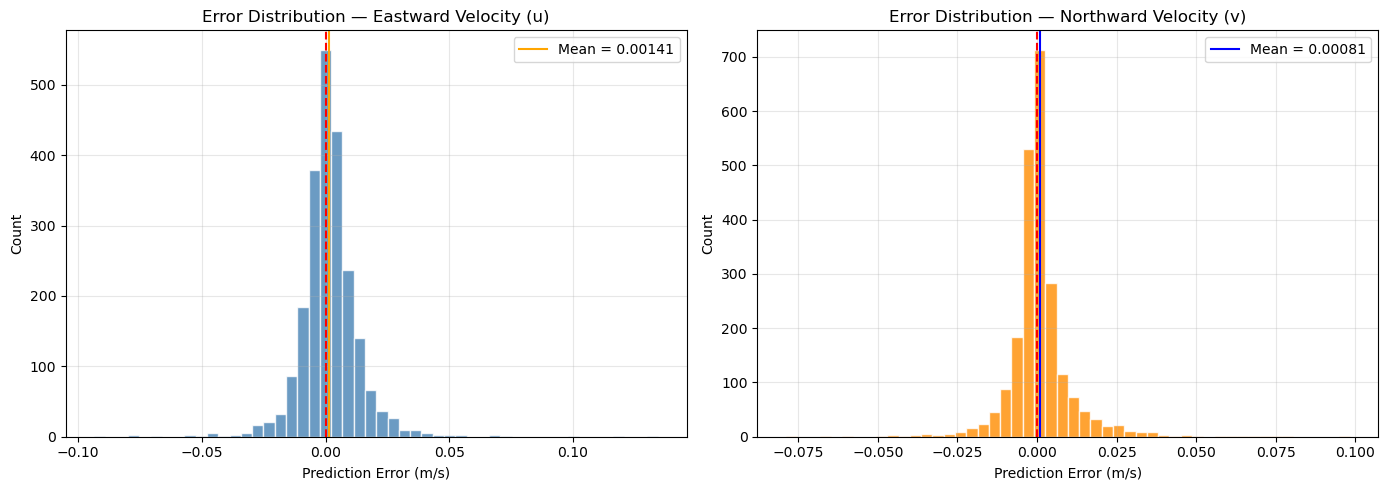

Error statistics (u): mean = 0.001415, std = 0.012384 m/s
Error statistics (v): mean = 0.000811, std = 0.010426 m/s


In [26]:
# Compute errors
error_u = df_results['pred_u'] - df_results['obs_u']
error_v = df_results['pred_v'] - df_results['obs_v']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error histogram for u
axes[0].hist(error_u, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[0].axvline(x=error_u.mean(), color='orange', linestyle='-', linewidth=1.5, 
                label=f'Mean = {error_u.mean():.5f}')
axes[0].set_xlabel('Prediction Error (m/s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Error Distribution — Eastward Velocity (u)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error histogram for v
axes[1].hist(error_v, bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(x=error_v.mean(), color='blue', linestyle='-', linewidth=1.5, 
                label=f'Mean = {error_v.mean():.5f}')
axes[1].set_xlabel('Prediction Error (m/s)')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Distribution — Northward Velocity (v)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Error statistics (u): mean = {error_u.mean():.6f}, std = {error_u.std():.6f} m/s")
print(f"Error statistics (v): mean = {error_v.mean():.6f}, std = {error_v.std():.6f} m/s")

### 12.4 Spatial Map of Prediction Errors

Where does our model make the biggest mistakes? This can reveal whether certain ocean regions are harder to predict.

C:\Users\ac685\anaconda3\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


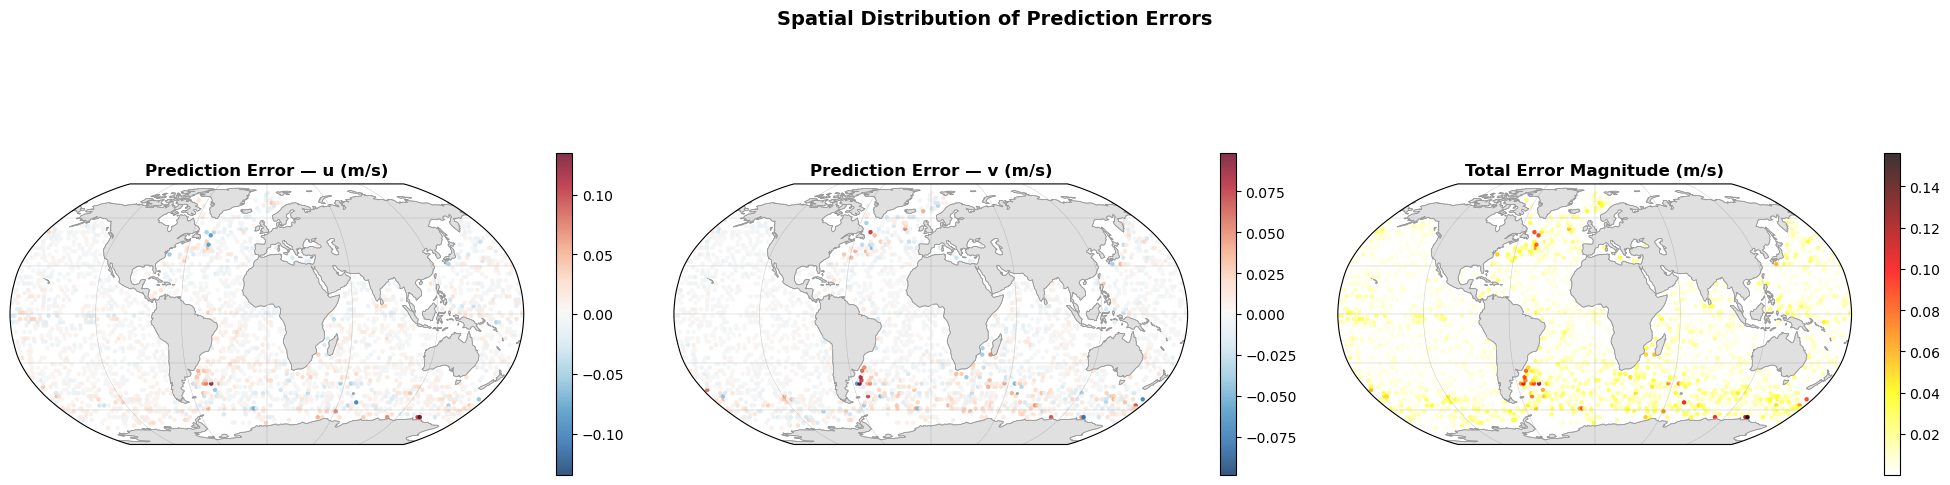

In [27]:
# Compute total vector error magnitude
error_magnitude = np.sqrt(error_u**2 + error_v**2)

fig, axes = plt.subplots(1, 3, figsize=(20, 6),
                         subplot_kw={'projection': ccrs.Robinson()})

for ax in axes:
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='#e0e0e0', edgecolor='#999999', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='#999999')
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

# Eastward error
vmax_u = max(abs(error_u.min()), abs(error_u.max()))
sc1 = axes[0].scatter(df_results['lon'].values, df_results['lat'].values, c=error_u, s=5,
                       cmap='RdBu_r', vmin=-vmax_u, vmax=vmax_u, alpha=0.8,
                       transform=ccrs.PlateCarree())
axes[0].set_title('Prediction Error — u (m/s)', fontsize=12, fontweight='bold')
plt.colorbar(sc1, ax=axes[0], shrink=0.6)

# Northward error
vmax_v = max(abs(error_v.min()), abs(error_v.max()))
sc2 = axes[1].scatter(df_results['lon'].values, df_results['lat'].values, c=error_v, s=5,
                       cmap='RdBu_r', vmin=-vmax_v, vmax=vmax_v, alpha=0.8,
                       transform=ccrs.PlateCarree())
axes[1].set_title('Prediction Error — v (m/s)', fontsize=12, fontweight='bold')
plt.colorbar(sc2, ax=axes[1], shrink=0.6)

# Total error magnitude
sc3 = axes[2].scatter(df_results['lon'].values, df_results['lat'].values, c=error_magnitude, s=5,
                       cmap='hot_r', alpha=0.8, transform=ccrs.PlateCarree())
axes[2].set_title('Total Error Magnitude (m/s)', fontsize=12, fontweight='bold')
plt.colorbar(sc3, ax=axes[2], shrink=0.6)

plt.suptitle('Spatial Distribution of Prediction Errors', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


---
## 13. Discussion and Next Steps

### What worked?

We successfully built a neural network that predicts ocean currents from hydrographic observations. The model learns a mapping from temperature, salinity, and their gradients to current velocities — capturing the complex, nonlinear relationships in the data.

### What could be improved?

There are many avenues for improvement. Here are some ideas to explore:

1. **Changing the ANN architectur setup**:
   - Try adding leass/more layers or less/more neurons per layer. Does it improve performance, or does it overfit?
   - What about using different activation functions (LeakyReLU, GELU), etc.? 

3. **Regularisation techniques**:
   - **Dropout**: Randomly deactivate neurons during training to prevent co-adaptation
   - **Weight decay**: Add L2 penalty to the loss function (`weight_decay` parameter in Adam)
   - **Batch normalisation**: Normalise activations within each layer

4. **Additional features**: Could we include `lat`, `lon`, or `n_cycles`? What about derived features like density or Brunt-Vaisala frequency?

5. **Learning rate scheduling**: What happens if you start with a higher learning rate and reduce it as training progresses

6. **Early stopping**: Stop training when validation loss stops improving, rather than training for a fixed number of epochs

### Exercises for further exploration

Try modifying the code above to answer these questions:

- **Exercise 1**: What happens if you train for 500 epochs instead of 200? Does the model overfit?
- **Exercise 2**: Add a `nn.Dropout(0.2)` layer after each ReLU. Does it help prevent overfitting?
- **Exercise 3**: Try a much simpler network (1 hidden layer, 16 neurons) and a much larger one (4 hidden layers, 128-64-32-16 neurons). How does the architecture affect performance?
- **Exercise 4**: Try adding `lat` and `lon` as input features. Does it improve predictions? Why might this be problematic for generalisation?

In [28]:
# Summary table
print("\n" + "=" * 60)
print("         FINAL SUMMARY — ANN Current Prediction")
print("=" * 60)
print(f"  Architecture:    7 → 64 → 32 → 16 → 2  (ReLU activations)")
print(f"  Parameters:      {total_params:,}")
print(f"  Training epochs: {n_epochs}")
print(f"  Batch size:      {batch_size}")
print(f"  Learning rate:   {learning_rate}")
print(f"  Training cells:  {X_train.shape[0]}")
print(f"  Validation cells:{X_val.shape[0]}")
print(f"  Gap-fill cells:  {len(df_results)}")
print(f"  ---")
print(f"  R² (u):          {r2_u:.4f}")
print(f"  R² (v):          {r2_v:.4f}")
print(f"  R² (speed):      {r2_speed:.4f}")
print(f"  RMSE (u):        {rmse_u:.6f} m/s")
print(f"  RMSE (v):        {rmse_v:.6f} m/s")
print(f"  RMSE (speed):    {rmse_speed:.6f} m/s")
print("=" * 60)
print("\nWell done! You've built your first neural network for")
print("ocean current reconstruction. 🌊")


         FINAL SUMMARY — ANN Current Prediction
  Architecture:    7 → 64 → 32 → 16 → 2  (ReLU activations)
  Parameters:      3,154
  Training epochs: 200
  Batch size:      64
  Learning rate:   0.001
  Training cells:  4127
  Validation cells:1032
  Gap-fill cells:  2272
  ---
  R² (u):          0.7537
  R² (v):          0.5121
  R² (speed):      0.7126
  RMSE (u):        0.012462 m/s
  RMSE (v):        0.010455 m/s
  RMSE (speed):    0.012693 m/s

Well done! You've built your first neural network for
ocean current reconstruction. 🌊
